In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/iashiqul/brain-stroke-prediction-ct-scan-image-dataset/Brain_Stroke_CT-SCAN_image/Validation/Stroke/68 (12).jpg
/kaggle/input/datasets/iashiqul/brain-stroke-prediction-ct-scan-image-dataset/Brain_Stroke_CT-SCAN_image/Validation/Stroke/88 (6).jpg
/kaggle/input/datasets/iashiqul/brain-stroke-prediction-ct-scan-image-dataset/Brain_Stroke_CT-SCAN_image/Validation/Stroke/66 (21) - Copy.jpg
/kaggle/input/datasets/iashiqul/brain-stroke-prediction-ct-scan-image-dataset/Brain_Stroke_CT-SCAN_image/Validation/Stroke/93 (17).jpg
/kaggle/input/datasets/iashiqul/brain-stroke-prediction-ct-scan-image-dataset/Brain_Stroke_CT-SCAN_image/Validation/Stroke/70 (37).jpg
/kaggle/input/datasets/iashiqul/brain-stroke-prediction-ct-scan-image-dataset/Brain_Stroke_CT-SCAN_image/Validation/Stroke/75 (18).jpg
/kaggle/input/datasets/iashiqul/brain-stroke-prediction-ct-scan-image-dataset/Brain_Stroke_CT-SCAN_image/Validation/Stroke/66 (15) - Copy.jpg
/kaggle/input/datasets/iashiqul/brain-stro

# Import Libraries
***

In [6]:
import os
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Model

from tensorflow.keras.applications.resnet50 import preprocess_input

# Reading The Data
***

In [3]:
DATASET_PATH = "/kaggle/input/datasets/iashiqul/brain-stroke-prediction-ct-scan-image-dataset/Brain_Stroke_CT-SCAN_image"

train_path = os.path.join(DATASET_PATH, "Train")
val_path = os.path.join(DATASET_PATH, "Validation")
test_path = os.path.join(DATASET_PATH, "Test")

# Verify
print(os.listdir(DATASET_PATH))

['Validation', 'Test', 'Train']


## Loading the Dataset

The CT scan images are loaded using TensorFlow's `image_dataset_from_directory()` utility, which automatically reads images from the dataset folders, assigns labels based on the directory names, and creates efficient `tf.data.Dataset` objects.

During this step, all images are resized to **224 × 224 pixels**, matching the input size required by most pre-trained convolutional neural networks. The training dataset is shuffled to improve model generalization, while the validation and test datasets remain unshuffled to ensure consistent evaluation.

In [17]:
# Image Configuration
IMG_HEIGHT = 224
IMG_WIDTH = 224

# Training Configuration
BATCH_SIZE = 32
SEED = 42
EPOCHS = 20

In [5]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_path,
    labels="inferred",
    label_mode="binary",
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    val_path,
    labels="inferred",
    label_mode="binary",
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_path,
    labels="inferred",
    label_mode="binary",
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    shuffle=False
)


# Verify
print("Class Names:", train_ds.class_names)

print("\nDataset Information")

for images, labels in train_ds.take(1):
    print(f"Image Batch Shape : {images.shape}")
    print(f"Label Batch Shape : {labels.shape}")
    print(f"Image Data Type   : {images.dtype}")
    print(f"Label Data Type   : {labels.dtype}")

Found 1843 files belonging to 2 classes.


I0000 00:00:1783460278.372975      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1783460278.375965      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Found 235 files belonging to 2 classes.
Found 437 files belonging to 2 classes.
Class Names: ['Normal', 'Stroke']

Dataset Information
Image Batch Shape : (32, 224, 224, 3)
Label Batch Shape : (32, 1)
Image Data Type   : <dtype: 'float32'>
Label Data Type   : <dtype: 'float32'>


## Image Normalization

Image normalization is an essential preprocessing step that prepares the input images for deep learning models. Instead of manually scaling pixel values, the images are preprocessed using the `preprocess_input()` function provided by the selected pre-trained model.

This function applies the same normalization technique that was used during the original ImageNet training, ensuring compatibility between the input images and the pre-trained network.

In [7]:
train_ds = train_ds.map(
    lambda images, labels: (preprocess_input(images), labels)
)

val_ds = val_ds.map(
    lambda images, labels: (preprocess_input(images), labels)
)

test_ds = test_ds.map(
    lambda images, labels: (preprocess_input(images), labels)
)


# Verify
for images, labels in train_ds.take(1):
    print("Minimum Pixel Value:", tf.reduce_min(images).numpy())
    print("Maximum Pixel Value:", tf.reduce_max(images).numpy())

Minimum Pixel Value: -123.68
Maximum Pixel Value: 151.061


## Data Augmentation

To improve the model's ability to generalize and reduce overfitting, data augmentation is applied to the training images. Since the dataset is relatively small, augmentation generates slightly modified versions of the original images during training.

Only medically appropriate transformations are used, including small rotations, translations, zooming, and horizontal flipping. Validation and test images are not augmented to ensure an unbiased evaluation of the model.

In [8]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.10),
    layers.RandomTranslation(
        height_factor=0.05,
        width_factor=0.05
    ),
], name="data_augmentation")

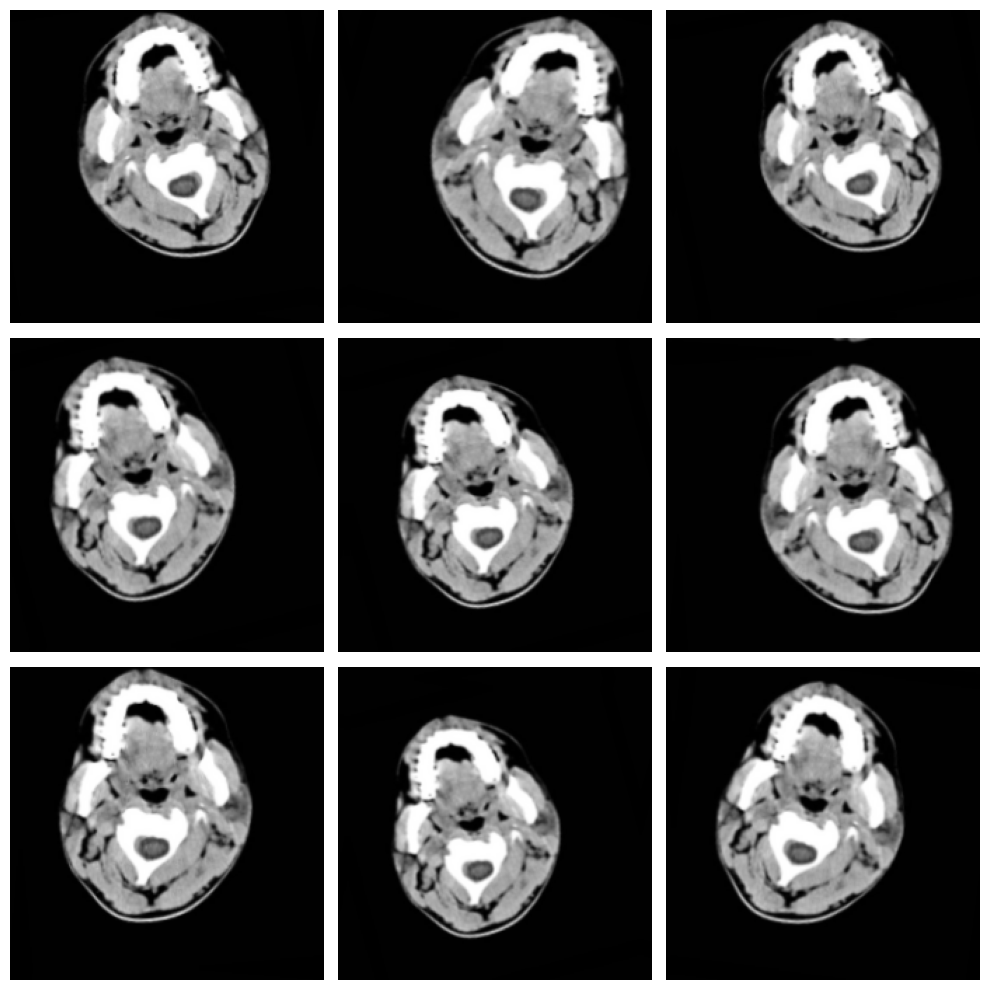

In [9]:
# Verify Augmentation
plt.figure(figsize=(10, 10))

for images, _ in train_ds.take(1):
    first_image = images[0]

    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)

        augmented_image = data_augmentation(
            tf.expand_dims(first_image, 0),
            training=True
        )

        plt.imshow(
            (augmented_image[0] + [103.939, 116.779, 123.68]) / 255.0
        )

        plt.axis("off")

plt.tight_layout()
plt.show()

## Dataset Performance Optimization

To improve the efficiency of the training pipeline, TensorFlow's data pipeline optimization techniques are applied.

- **Cache** stores the dataset after the first iteration, reducing disk access in subsequent epochs.
- **Prefetch** overlaps data preprocessing and model execution, allowing the CPU to prepare future batches while the GPU processes the current batch.

These optimizations improve training speed without affecting model performance.

In [10]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

## Model Development

A transfer learning approach is adopted using the pre-trained **ResNet50** architecture. Instead of training a convolutional neural network from scratch, the model leverages features learned from the large-scale ImageNet dataset.

Initially, the convolutional base is used as a fixed feature extractor by freezing its weights. A custom classification head is then added to adapt the network to the binary stroke classification task.

In [11]:
from tensorflow.keras.applications import ResNet50

base_model = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)


# Verify
print(base_model.input_shape)
print(base_model.output_shape)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
(None, 224, 224, 3)
(None, 7, 7, 2048)


## Freezing the Pre-trained Model

The convolutional layers of the pre-trained ResNet50 model are frozen during the initial training phase. This allows the network to act as a fixed feature extractor while only the newly added classification layers are trained.

Freezing the base model reduces training time, minimizes the risk of overfitting, and preserves the valuable features learned from the ImageNet dataset. Fine-tuning can be applied later by unfreezing selected layers.

In [12]:
base_model.trainable = False

# Verify
print("Base Model Trainable:", base_model.trainable)

Base Model Trainable: False


## Building the Classification Head

The original classification layer of ResNet50 is removed and replaced with a custom classification head designed for binary stroke detection.

A **Global Average Pooling** layer is used to reduce the spatial feature maps into a compact feature vector while preserving the most important information. This is followed by a fully connected layer with ReLU activation to learn task-specific patterns. A **Dropout** layer is added to reduce overfitting, and the final output layer consists of a single neuron with a **Sigmoid** activation function to predict the probability of the image belonging to the stroke class.

In [13]:
from tensorflow.keras.layers import (
    GlobalAveragePooling2D,
    Dense,
    Dropout,
    Input
)

from tensorflow.keras.models import Model


inputs = Input(shape=(224, 224, 3))
x = base_model(inputs, training=False)
base_model.trainable = False
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation="relu")(x)
x = Dropout(0.5)(x)
outputs = Dense(1, activation="sigmoid")(x)

# Building The Model
model = Model(inputs, outputs)

# Verify
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,112,513 (91.98 MB)

 Trainable params: 524,801 (2.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

## Model Compilation

The model is compiled using the **Adam** optimizer, which provides efficient gradient-based optimization and is widely used in deep learning applications.

Since the task is binary classification (Normal vs. Stroke), the **Binary Crossentropy** loss function is used together with a **Sigmoid** output layer.

In addition to accuracy, several evaluation metrics are monitored, including **Precision**, **Recall**, and **AUC**, to provide a more comprehensive assessment of the model's performance on this medical imaging task.

In [15]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),

    loss="binary_crossentropy",

    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),
        tf.keras.metrics.AUC(name="auc")
    ]
)

## Training Callbacks

Several callbacks are used during training to improve the learning process and prevent overfitting.

- **EarlyStopping** monitors the validation loss and stops training when no improvement is observed.
- **ModelCheckpoint** saves the best-performing model based on the validation loss.
- **ReduceLROnPlateau** automatically reduces the learning rate when the validation loss stops improving, allowing the optimizer to converge more effectively.

In [18]:
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint,
    ReduceLROnPlateau
)


early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)


checkpoint = ModelCheckpoint(
    "best_resnet50_model.keras",
    monitor="val_loss",
    save_best_only=True
)


reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=3,
    min_lr=1e-6
)


callbacks = [
    early_stopping,
    checkpoint,
    reduce_lr
]

In [19]:
# Start Training
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks
)

Epoch 1/20
 1/58 ━━━━━━━━━━━━━━━━━━━━ 16:11 17s/step - accuracy: 0.6562 - auc: 0.7639 - loss: 0.6469 - precision: 0.6522 - recall: 0.8333

I0000 00:00:1783467908.161217     143 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


58/58 ━━━━━━━━━━━━━━━━━━━━ 41s 412ms/step - accuracy: 0.5638 - auc: 0.5531 - loss: 0.8098 - precision: 0.4641 - recall: 0.4101 - val_accuracy: 0.7532 - val_auc: 0.7489 - val_loss: 0.5800 - val_precision: 0.6562 - val_recall: 0.5385 - learning_rate: 1.0000e-04
Epoch 2/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 6s 106ms/step - accuracy: 0.6403 - auc: 0.6726 - loss: 0.6477 - precision: 0.5732 - recall: 0.4815 - val_accuracy: 0.7064 - val_auc: 0.7941 - val_loss: 0.5905 - val_precision: 0.5405 - val_recall: 0.7692 - learning_rate: 1.0000e-04
Epoch 3/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 7s 125ms/step - accuracy: 0.6858 - auc: 0.7417 - loss: 0.5874 - precision: 0.6425 - recall: 0.5278 - val_accuracy: 0.7617 - val_auc: 0.8119 - val_loss: 0.5503 - val_precision: 0.6122 - val_recall: 0.7692 - learning_rate: 1.0000e-04
Epoch 4/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 7s 125ms/step - accuracy: 0.7179 - auc: 0.7700 - loss: 0.5596 - precision: 0.6777 - recall: 0.5952 - val_accuracy: 0.7830 - val_auc: 0.8358 - val_loss: 0.5222 - v

# Model Evaluation

The trained model is evaluated on the unseen test dataset to assess its generalization performance. Multiple evaluation metrics are reported, including loss, accuracy, precision, recall, and AUC, providing a comprehensive assessment of the model's performance on stroke detection.

In [23]:
results = model.evaluate(test_ds, return_dict=True)

for metric, value in results.items():
    print(f"{metric}: {value:.4f}")

14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 101ms/step - accuracy: 0.8124 - auc: 0.8862 - loss: 0.4243 - precision: 0.6519 - recall: 0.7923       
accuracy: 0.8124
auc: 0.8862
loss: 0.4243
precision: 0.6519
recall: 0.7923


## Training History

The training and validation curves are visualized to monitor the learning process and detect potential overfitting or underfitting during training.

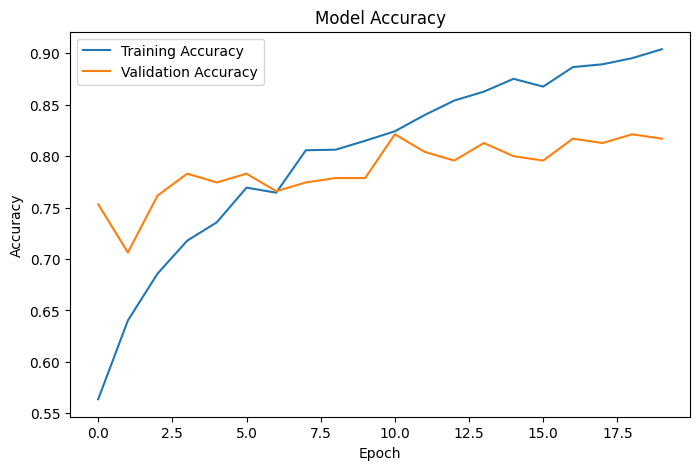

In [21]:
plt.figure(figsize=(8,5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

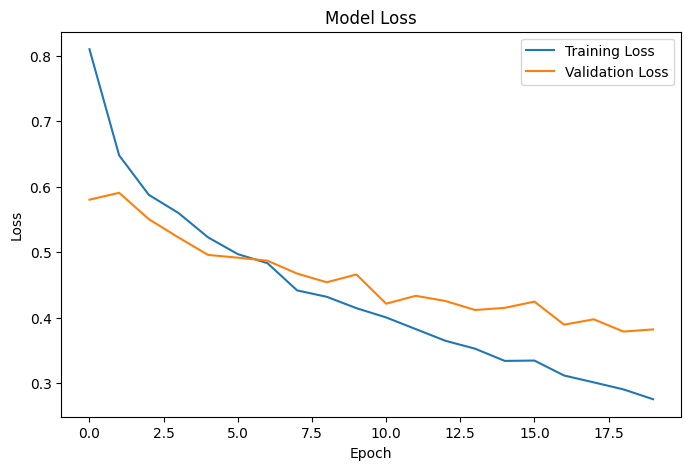

In [22]:
plt.figure(figsize=(8,5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

In [24]:
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)


y_prob = model.predict(test_ds)

y_pred = (y_prob >= 0.5).astype(int)

y_true = np.concatenate(
    [labels for _, labels in test_ds],
    axis=0
).astype(int)

cm = confusion_matrix(y_true, y_pred)

14/14 ━━━━━━━━━━━━━━━━━━━━ 10s 434ms/step


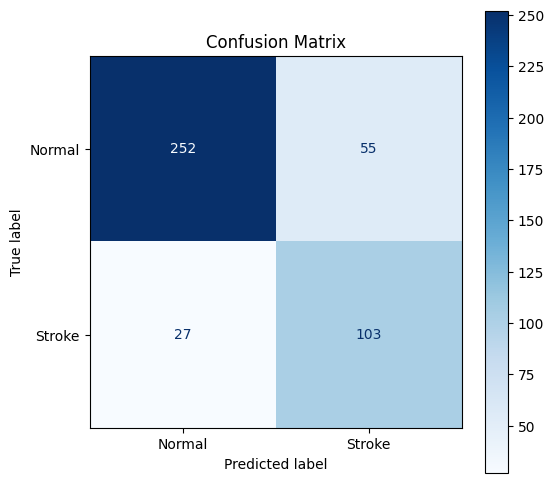

In [25]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Normal", "Stroke"]
)

fig, ax = plt.subplots(figsize=(6,6))
disp.plot(cmap="Blues", ax=ax)

plt.title("Confusion Matrix")
plt.show()

In [26]:
print(classification_report(
    y_true,
    y_pred,
    target_names=["Normal","Stroke"]
))

              precision    recall  f1-score   support

      Normal       0.90      0.82      0.86       307
      Stroke       0.65      0.79      0.72       130

    accuracy                           0.81       437
   macro avg       0.78      0.81      0.79       437
weighted avg       0.83      0.81      0.82       437

